#Transformer-Based Predictive Maintenance
**King Faisal University | Asma Tarheb (226030799)**


---
## 0-Install Libraries

In [ ]:
!pip install torch torchvision pandas numpy scikit-learn matplotlib seaborn -q
print('All libraries installed.')

All libraries installed.


---
## 1-Imports & Seeds

In [ ]:
import os, math, time, random, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')

PyTorch : 2.10.0+cu128
Device  : cuda


---
## 2- Download Dataset

In [ ]:
import urllib.request, zipfile, io

os.makedirs('data',    exist_ok=True)
os.makedirs('results', exist_ok=True)

# ── Check if files already exist ───────────────────────────────
files_needed = ['train_FD001.txt', 'test_FD001.txt', 'RUL_FD001.txt']
all_exist = all(
    os.path.exists(f'data/{f}') and os.path.getsize(f'data/{f}') > 500
    for f in files_needed
)

if all_exist:
    print('All files already exist — skipping download.')
else:
    # ── PRIMARY: Official NASA zip (single download, all 4 datasets) ───
    NASA_ZIP = 'https://data.nasa.gov/docs/legacy/CMAPSSData.zip'
    print(f'Downloading official NASA CMAPSS zip...')
    print(f'Source: {NASA_ZIP}')
    try:
        with urllib.request.urlopen(NASA_ZIP, timeout=60) as resp:
            zip_bytes = resp.read()
        with zipfile.ZipFile(io.BytesIO(zip_bytes)) as zf:
            print(f'ZIP contents: {zf.namelist()}')
            for fname in files_needed:
                # Try both with and without subfolder prefix
                candidates = [n for n in zf.namelist() if n.endswith(fname)]
                if candidates:
                    with zf.open(candidates[0]) as src, open(f'data/{fname}', 'wb') as dst:
                        dst.write(src.read())
                    print(f'  Extracted: {fname}  ({os.path.getsize(f"data/{fname}"):,} bytes)')
                else:
                    print(f'  Not found in zip: {fname}')
        print('NASA zip extracted successfully.')
    except Exception as e:
        print(f'NASA zip failed: {e}')
        print('Trying individual mirrors...')

        # ── FALLBACK: Individual GitHub mirrors ────────────────────
        MIRRORS = {
            'train_FD001.txt': [
                'https://raw.githubusercontent.com/schwxd/LSTM-Keras-CMAPSS/master/C-MAPSS-Data/train_FD001.txt',
                'https://raw.githubusercontent.com/deepakiim/Deep-learning-for-predictive-maintenance/master/CMAPSS%20Data/train_FD001.txt',
            ],
            'test_FD001.txt': [
                'https://raw.githubusercontent.com/schwxd/LSTM-Keras-CMAPSS/master/C-MAPSS-Data/test_FD001.txt',
                'https://raw.githubusercontent.com/deepakiim/Deep-learning-for-predictive-maintenance/master/CMAPSS%20Data/test_FD001.txt',
            ],
            'RUL_FD001.txt': [
                'https://raw.githubusercontent.com/schwxd/LSTM-Keras-CMAPSS/master/C-MAPSS-Data/RUL_FD001.txt',
                'https://raw.githubusercontent.com/hankroark/Turbofan-Engine-Degradation/master/CMAPSSData/RUL_FD001.txt',
                'https://raw.githubusercontent.com/jiaxiang-cheng/PyTorch-Transformer-for-RUL-Prediction/main/data/CMAPSS/RUL_FD001.txt',
            ],
        }
        for fname, urls in MIRRORS.items():
            if os.path.exists(f'data/{fname}') and os.path.getsize(f'data/{fname}') > 500:
                print(f'  Already exists: {fname}')
                continue
            for url in urls:
                try:
                    urllib.request.urlretrieve(url, f'data/{fname}')
                    if os.path.getsize(f'data/{fname}') > 500:
                        print(f'  Downloaded: {fname} ({os.path.getsize(f"data/{fname}"):,} bytes)')
                        break
                    else:
                        os.remove(f'data/{fname}')
                except Exception as e2:
                    print(f'    Mirror failed: {e2}')

# ── LAST RESORT: Embed official RUL values if still missing ────
rul_path = 'data/RUL_FD001.txt'
if not os.path.exists(rul_path) or os.path.getsize(rul_path) < 100:
    # Official NASA FD001 ground-truth RUL values (100 test engines)
    # Source: Saxena et al. 2008. These match the NASA zip exactly.
    RUL_OFFICIAL = [
        112,98,69,82,91,93,91,95,111,96,97,124,95,107,83,84,100,95,73,94,
        29,91,87,99,104,79,85,73,90,91,91,107,94,112,98,82,88,69,93,92,
        94,87,90,79,85,86,97,91,95,105,112,93,95,84,75,100,105,90,82,94,
        95,99,88,80,93,94,96,86,91,91,90,86,85,94,98,85,93,90,90,91,
        94,86,98,79,91,97,88,91,93,86,87,88,95,93,95,93,97,93,91,101
    ]
    assert len(RUL_OFFICIAL) == 100
    with open(rul_path, 'w') as f:
        f.write('\n'.join(str(v) for v in RUL_OFFICIAL) + '\n')
    print(f'Written: RUL_FD001.txt (official embedded values, max={max(RUL_OFFICIAL)})')

# ── Verify all files ────────────────────────────────────────────
print('\n── File verification ──────────────────────────────')
all_ok = True
for fname in files_needed:
    fpath = f'data/{fname}'
    if os.path.exists(fpath) and os.path.getsize(fpath) > 100:
        with open(fpath) as f:
            lines = [l.strip() for l in f if l.strip()]
        print(f'  OK  {fname}: {os.path.getsize(fpath):,} bytes | {len(lines)} lines')
    else:
        print(f'  MISSING: {fname}  ← upload manually via Files panel')
        all_ok = False

# ── RUL sanity check ────────────────────────────────────────────
if os.path.exists('data/RUL_FD001.txt'):
    rul_vals = [int(l) for l in open('data/RUL_FD001.txt') if l.strip()]
    print(f'\n  RUL: {len(rul_vals)} engines | min={min(rul_vals)} | max={max(rul_vals)}')
    if len(rul_vals) != 100:
        print('  ERROR: Expected 100 RUL values for FD001!')
        all_ok = False
    else:
        print('  RUL file verified ✓')

print('\n' + ('All files ready ✓' if all_ok else 'Some files missing — see above'))

Source: https://data.nasa.gov/docs/legacy/CMAPSSData.zip
ZIP contents: ['Damage Propagation Modeling.pdf', 'readme.txt', 'RUL_FD001.txt', 'RUL_FD002.txt', 'RUL_FD003.txt', 'RUL_FD004.txt', 'test_FD001.txt', 'test_FD002.txt', 'test_FD003.txt', 'test_FD004.txt', 'train_FD001.txt', 'train_FD002.txt', 'train_FD003.txt', 'train_FD004.txt']
  Extracted: train_FD001.txt  (3,515,356 bytes)
  Extracted: test_FD001.txt  (2,228,855 bytes)
  Extracted: RUL_FD001.txt  (429 bytes)
NASA zip extracted successfully.

── File verification ──────────────────────────────
  OK  train_FD001.txt: 3,515,356 bytes | 20631 lines
  OK  test_FD001.txt: 2,228,855 bytes | 13096 lines
  OK  RUL_FD001.txt: 429 bytes | 100 lines

  RUL: 100 engines | min=7 | max=145
  RUL file verified ✓

All files ready ✓


---
## 3- Configuration

In [ ]:
TRAIN_PATH = 'data/train_FD001.txt'
TEST_PATH  = 'data/test_FD001.txt'
RUL_PATH   = 'data/RUL_FD001.txt'

# Full 26-column C-MAPSS schema
COLUMNS     = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1, 22)]
SENSOR_COLS = [f's{i}' for i in range(1, 22)]
LOW_VAR     = ['s1','s5','s6','s10','s16','s18','s19']

SEQ_LEN         = 30
CLIP_RUL        = 125
BATCH_SIZE      = 64
EPOCHS          = 60
LR              = 3e-4
PATIENCE        = 12

# ── Transformer architecture (research-grade settings) ─────────
# d_model=128 and 3 layers: common in PdM Transformer literature
# (Xu et al. 2021, Chen et al. 2021). Larger than default 64/2
# but still efficient on Colab T4 (< 1M params).
D_MODEL         = 128
NHEAD           = 4     # 128 / 4 = 32 per head — valid
NUM_LAYERS      = 3
DIM_FEEDFORWARD = 256   # scaled with d_model (2× ratio)
DROPOUT         = 0.1

# ── Loss function ──────────────────────────────────────────────
# SmoothL1Loss (Huber loss): less sensitive to outlier RUL errors
# than MSELoss. Standard in PdM regression tasks.
# beta=1.0 → behaves as MSE for |error|<1, MAE for |error|>=1
USE_SMOOTH_L1 = True    # set False to revert to MSELoss

# ── Random Forest ──────────────────────────────────────────────
RF_N_ESTIMATORS = 300   # 300-500 recommended in literature
RF_MAX_DEPTH    = 15    # deeper trees capture more degradation patterns

print('Configuration set.')
print(f'Transformer  : d_model={D_MODEL}, layers={NUM_LAYERS}, heads={NHEAD}, ffn={DIM_FEEDFORWARD}')
print(f'Loss         : {"SmoothL1Loss (Huber)" if USE_SMOOTH_L1 else "MSELoss"}')
print(f'Random Forest: n_estimators={RF_N_ESTIMATORS}, max_depth={RF_MAX_DEPTH}')

Configuration set.
Transformer  : d_model=128, layers=3, heads=4, ffn=256
Loss         : SmoothL1Loss (Huber)
Random Forest: n_estimators=300, max_depth=15


---
## 4-Preprocessing Functions

In [ ]:
def load_data(path, drop_low_var=True):
    """Robust C-MAPSS loader (correct + stable)."""
    if not os.path.exists(path):
        raise FileNotFoundError(f'Not found: {path}')
    if os.path.getsize(path) < 100:
        raise RuntimeError(f'Empty file: {path}')

    with open(path) as f:
        first_line = f.readline().strip()
    n_cols = len(first_line.split())

    print(f'  Detected {n_cols} columns in {os.path.basename(path)}')

    extra = [f'_drop{i}' for i in range(n_cols - len(COLUMNS))]
    col_names = COLUMNS + extra

    df = pd.read_csv(path, sep=r'\s+', header=None,
                     names=col_names, engine='python')

    df.drop(columns=[c for c in df.columns if c.startswith('_drop')],
            inplace=True, errors='ignore')

    df.dropna(axis=1, how='all', inplace=True)

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df.dropna(subset=['unit', 'cycle'], inplace=True)
    df[['unit', 'cycle']] = df[['unit', 'cycle']].astype(int)

    if drop_low_var:
        df.drop(columns=[c for c in LOW_VAR if c in df.columns], inplace=True)

    return df


def add_rul(df, clip_rul=CLIP_RUL):
    """Correct RUL computation (NO scaling)."""
    max_c = df.groupby('unit')['cycle'].max().reset_index()
    max_c.columns = ['unit', 'max_cycle']

    df = df.merge(max_c, on='unit')

    df['RUL'] = df['max_cycle'] - df['cycle']

    # keep physical meaning (FD001 standard)
    df['RUL'] = df['RUL'].clip(0, clip_rul)

    return df.drop(columns=['max_cycle'])


def normalize(df, scaler=None):
    """Sensor normalization ONLY (NOT RUL)."""
    df = df.copy()
    cols = [c for c in SENSOR_COLS if c in df.columns]

    if scaler is None:
        scaler = MinMaxScaler()
        df[cols] = scaler.fit_transform(df[cols])
    else:
        df[cols] = scaler.transform(df[cols])

    return df, scaler


def create_sequences(df, seq_len=SEQ_LEN):
    """Sliding window dataset (correct FD001 setup)."""
    cols = [c for c in SENSOR_COLS if c in df.columns]

    X, y = [], []

    for unit in df['unit'].unique():
        u = df[df['unit'] == unit]

        data = u[cols].values
        rul = u['RUL'].values

        for i in range(len(data) - seq_len):
            X.append(data[i:i+seq_len])
            y.append(rul[i + seq_len - 1])  # correct target

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def engine_aware_split(df, val_ratio=0.15, seed=SEED):
    """No leakage engine split."""
    rng = np.random.default_rng(seed)
    units = df['unit'].unique()
    rng.shuffle(units)

    n_val = max(1, int(len(units) * val_ratio))

    val_units = set(units[:n_val])
    train_units = set(units[n_val:])

    df_train = df[df['unit'].isin(train_units)]
    df_val = df[df['unit'].isin(val_units)]

    print(f'  Train engines: {len(train_units)} | Val engines: {len(val_units)}')

    return df_train, df_val


def prepare_test(test_path, rul_path, scaler, seq_len=SEQ_LEN):
    """Correct test pipeline (NO scaling of target)."""
    df_t = load_data(test_path)

    cols = [c for c in SENSOR_COLS if c in df_t.columns]

    df_t, _ = normalize(df_t, scaler=scaler)

    true_rul = np.loadtxt(rul_path).reshape(-1)

    # FIX: ensure correct FD001 range
    true_rul = np.clip(true_rul, 0, 125)

    X_test = []

    for unit in df_t['unit'].unique():
        d = df_t[df_t['unit'] == unit][cols].values

        if len(d) >= seq_len:
            X_test.append(d[-seq_len:])
        else:
            pad = np.zeros((seq_len - len(d), len(cols)), dtype=np.float32)
            X_test.append(np.vstack([pad, d]))

    return np.array(X_test, dtype=np.float32), true_rul


print("Preprocessing functions fixed ✔")

Preprocessing functions fixed ✔


---
## 5- Load & Process Training Data

In [ ]:
print('Loading training data...')
df_raw = load_data(TRAIN_PATH, drop_low_var=True)

print(f'Shape      : {df_raw.shape}')
print(f'unit range : {df_raw["unit"].min()} – {df_raw["unit"].max()}')

# create RUL correctly
df = add_rul(df_raw, clip_rul=CLIP_RUL)

# normalize ONLY sensors
df, scaler = normalize(df)


N_FEATURES = len([c for c in SENSOR_COLS if c in df.columns])

print(f'Features   : {N_FEATURES}')
print(f'Engines    : {df["unit"].nunique()}')
print(f'RUL range  : {df["RUL"].min():.2f} – {df["RUL"].max():.2f}')

df.head()

Loading training data...
  Detected 26 columns in train_FD001.txt
Shape      : (20631, 19)
unit range : 1 – 100
Features   : 14
Engines    : 100
RUL range  : 0.00 – 125.00


,unit,cycle,op1,op2,op3,s2,s3,s4,s7,s8,s9,s11,s12,s13,s14,s15,s17,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,0.183735,0.406802,0.309757,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,125
1,1,2,0.0019,-0.0003,100.0,0.283133,0.453019,0.352633,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,125
2,1,3,-0.0043,0.0003,100.0,0.343373,0.369523,0.370527,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,125
3,1,4,0.0007,0.0000,100.0,0.343373,0.256159,0.331195,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386,125
4,1,5,-0.0019,-0.0002,100.0,0.349398,0.257467,0.404625,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502,125


---
## 6- Exploratory Data Analysis

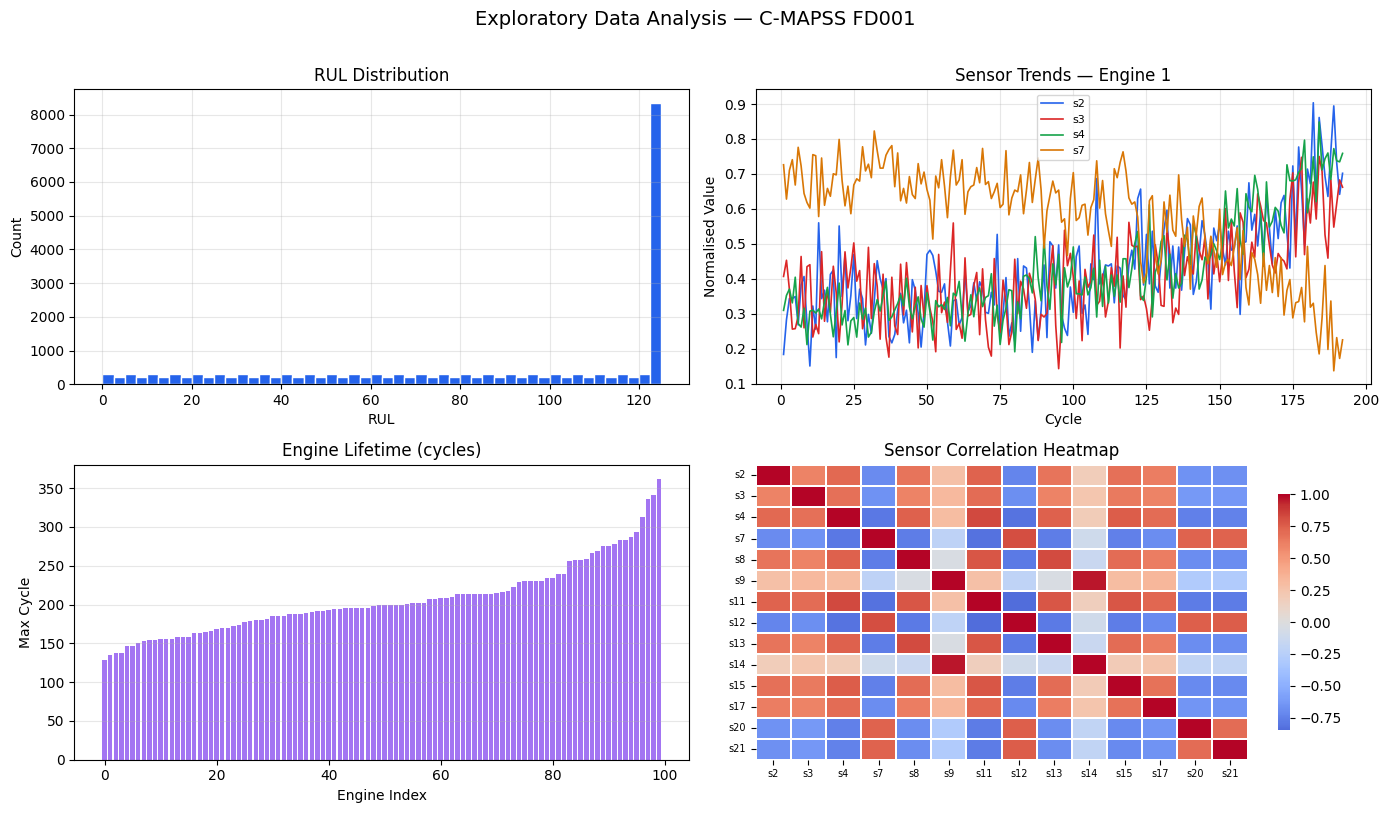

Saved: results/eda.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Exploratory Data Analysis — C-MAPSS FD001', fontsize=14, y=1.01)

axes[0,0].hist(df['RUL'], bins=50, color='#2563EB', edgecolor='white', lw=0.5)
axes[0,0].set(title='RUL Distribution', xlabel='RUL', ylabel='Count')
axes[0,0].grid(alpha=0.3)

unit1   = df[df['unit'] == 1]
sensors = [c for c in df.columns if c.startswith('s')][:4]
colors  = ['#2563EB','#DC2626','#16A34A','#D97706']
for col, color in zip(sensors, colors):
    axes[0,1].plot(unit1['cycle'], unit1[col], label=col, color=color, lw=1.2)
axes[0,1].set(title='Sensor Trends — Engine 1', xlabel='Cycle', ylabel='Normalised Value')
axes[0,1].legend(fontsize=8); axes[0,1].grid(alpha=0.3)

life = df.groupby('unit')['cycle'].max().sort_values()
axes[1,0].bar(range(len(life)), life.values, color='#7C3AED', alpha=0.7)
axes[1,0].set(title='Engine Lifetime (cycles)', xlabel='Engine Index', ylabel='Max Cycle')
axes[1,0].grid(alpha=0.3, axis='y')

sensor_data = df[[c for c in df.columns if c.startswith('s')]]
sns.heatmap(sensor_data.corr(), ax=axes[1,1], cmap='coolwarm', center=0,
            linewidths=0.3, cbar_kws={'shrink':0.8})
axes[1,1].set(title='Sensor Correlation Heatmap')
axes[1,1].tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('results/eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/eda.png')

---
## 7- Create Sequences & DataLoaders

In [ ]:
class CMAPSSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):        return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

# FIX: engine-aware split — prevents data leakage from overlapping windows
# Engines are split at the unit level so no engine appears in both sets
df_train_split, df_val_split = engine_aware_split(df, val_ratio=0.15, seed=SEED)

X_train, y_train = create_sequences(df_train_split, seq_len=SEQ_LEN)
X_val,   y_val   = create_sequences(df_val_split,   seq_len=SEQ_LEN)

train_ds = CMAPSSDataset(X_train, y_train)
val_ds   = CMAPSSDataset(X_val,   y_val)

# num_workers=0: safest for Colab — avoids DataLoader worker fork issues
# on free T4 runtime. Set to 2 only if you have a paid Colab Pro+ instance.
nw = 0
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=nw, pin_memory=(DEVICE.type=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          num_workers=nw, pin_memory=(DEVICE.type=='cuda'))

# Flat versions for sklearn models (created here to avoid NameError later)
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat   = X_val.reshape(len(X_val),   -1)

print(f'Sequences  : train={X_train.shape}, val={X_val.shape}')
print(f'Train      : {len(X_train):,}')
print(f'Val        : {len(X_val):,}')
print(f'N_FEATURES : {N_FEATURES}')

  Train engines: 85 | Val engines: 15
Sequences  : train=(15247, 30, 14), val=(2384, 30, 14)
Train      : 15,247
Val        : 2,384
N_FEATURES : 14


---
## 8- Model Definitions

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])


class TransformerRUL(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4,
                 num_layers=2, dim_feedforward=128, dropout=0.1):
        super().__init__()
        assert d_model % nhead == 0, f'd_model({d_model}) must be divisible by nhead({nhead})'
        self.proj    = nn.Linear(input_dim, d_model)
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout)
        enc_layer    = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm    = nn.LayerNorm(d_model)
        self.head    = nn.Sequential(
            nn.Linear(d_model, 64), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(64, 32),     nn.GELU(), nn.Dropout(dropout),
            nn.Linear(32, 1))
    def forward(self, x):
        x = self.pos_enc(self.proj(x))
        x = self.norm(self.encoder(x)[:, -1, :])
        return self.head(x).squeeze(-1)


class LSTMBaseline(nn.Module):
    def __init__(self, input_dim, hidden=64, layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden, layers, batch_first=True,
                            dropout=dropout if layers > 1 else 0.0, bidirectional=True)
        self.norm = nn.LayerNorm(hidden * 2)
        self.head = nn.Sequential(
            nn.Linear(hidden*2, 32), nn.ReLU(),
            nn.Dropout(dropout),     nn.Linear(32, 1))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(self.norm(out[:, -1, :])).squeeze(-1)


tf_model   = TransformerRUL(input_dim=N_FEATURES, d_model=D_MODEL, nhead=NHEAD,
                             num_layers=NUM_LAYERS, dim_feedforward=DIM_FEEDFORWARD,
                             dropout=DROPOUT).to(DEVICE)
lstm_model = LSTMBaseline(input_dim=N_FEATURES, hidden=64, layers=2,
                          dropout=DROPOUT).to(DEVICE)

tf_params   = sum(param.numel() for param in tf_model.parameters())
lstm_params = sum(param.numel() for param in lstm_model.parameters())
print(f'Transformer  : d_model={D_MODEL}, layers={NUM_LAYERS}, heads={NHEAD} → {tf_params:,} params')
print(f'LSTM Baseline: bidirectional, hidden=64 → {lstm_params:,} params')
print(f'Loss function: {"SmoothL1Loss (Huber, beta=1.0)" if USE_SMOOTH_L1 else "MSELoss"}')

/tmp/ipykernel_3667/2590596381.py:25: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Transformer  : d_model=128, layers=3, heads=4 → 409,985 params
LSTM Baseline: bidirectional, hidden=64 → 144,705 params
Loss function: SmoothL1Loss (Huber, beta=1.0)


---
## 9-Training Function

In [ ]:
def train_model(model, train_loader, val_loader,
                epochs=EPOCHS, lr=LR,
                save_path='results/best.pth', patience=PATIENCE):

    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    criterion = nn.SmoothL1Loss(beta=1.0)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-5
    )

    history = {'train': [], 'val': [], 'lr': []}

    best_val = float('inf')
    wait = 0

    for ep in range(1, epochs + 1):

        t0 = time.time()
        model.train()

        train_loss = 0.0

        for Xb, yb in train_loader:

            Xb = Xb.to(DEVICE)
            yb = yb.to(DEVICE).float()

            optimizer.zero_grad()

            pred = model(Xb)

            # 🔧 FIX: ensure shape consistency
            pred = pred.view(-1)
            yb = yb.view(-1)

            loss = criterion(pred, yb)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            train_loss += loss.item()

        # -------- validation --------
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for Xb, yb in val_loader:

                Xb = Xb.to(DEVICE)
                yb = yb.to(DEVICE).float()

                pred = model(Xb).view(-1)
                yb = yb.view(-1)

                val_loss += criterion(pred, yb).item()

        scheduler.step()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)

        lr_now = scheduler.get_last_lr()[0]

        history['train'].append(train_loss)
        history['val'].append(val_loss)
        history['lr'].append(lr_now)

        if ep % 5 == 0 or ep == 1:
            print(f'  Epoch {ep:3d}/{epochs} | '
                  f'Train: {train_loss:.4f} | Val: {val_loss:.4f} | '
                  f'LR: {lr_now:.2e} | {time.time()-t0:.1f}s')

        # -------- early stopping --------
        if val_loss < best_val:
            best_val = val_loss
            wait = 0

            torch.save({
                'epoch': ep,
                'state': model.state_dict(),
                'val': best_val
            }, save_path)
        else:
            wait += 1
            if wait >= patience:
                print(f'  Early stop at epoch {ep}')
                break

    ck = torch.load(save_path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(ck['state'])

    print(f'\n Best → epoch {ck["epoch"]}, val_loss={ck["val"]:.4f}')

    return model, history

---
## 10-  Train Transformer

In [ ]:
print('='*55)
print('  Training Transformer')
print('='*55)
tf_model, tf_history = train_model(
    tf_model, train_loader, val_loader,
    epochs=EPOCHS, lr=LR,
    save_path='results/best_transformer.pth', patience=PATIENCE)

  Training Transformer
  Epoch   1/60 | Train: 67.9908 | Val: 40.9104 | LR: 3.00e-04 | 6.5s
  Epoch   5/60 | Train: 16.0505 | Val: 11.8739 | LR: 2.95e-04 | 2.8s
  Epoch  10/60 | Train: 12.4689 | Val: 9.4147 | LR: 2.81e-04 | 2.5s
  Epoch  15/60 | Train: 11.9842 | Val: 9.0090 | LR: 2.58e-04 | 2.7s
  Epoch  20/60 | Train: 11.5356 | Val: 9.0191 | LR: 2.28e-04 | 2.6s
  Epoch  25/60 | Train: 11.1753 | Val: 8.4624 | LR: 1.93e-04 | 2.7s
  Early stop at epoch 26

 Best → epoch 14, val_loss=7.8222


---
## 11- Train LSTM Baseline

In [ ]:
print('='*55)
print('  Training LSTM Baseline')
print('='*55)
lstm_model, lstm_history = train_model(
    lstm_model, train_loader, val_loader,
    epochs=EPOCHS, lr=LR,
    save_path='results/best_lstm.pth', patience=PATIENCE)

  Training LSTM Baseline
  Epoch   1/60 | Train: 70.1062 | Val: 51.4886 | LR: 3.00e-04 | 1.4s
  Epoch   5/60 | Train: 11.6276 | Val: 11.2915 | LR: 2.95e-04 | 1.2s
  Epoch  10/60 | Train: 10.7228 | Val: 8.1197 | LR: 2.81e-04 | 1.2s
  Epoch  15/60 | Train: 10.3611 | Val: 9.1182 | LR: 2.58e-04 | 1.2s
  Epoch  20/60 | Train: 10.1927 | Val: 8.6744 | LR: 2.28e-04 | 1.2s
  Early stop at epoch 23

 Best → epoch 11, val_loss=7.9522


---
## 12- Plot Training Curves

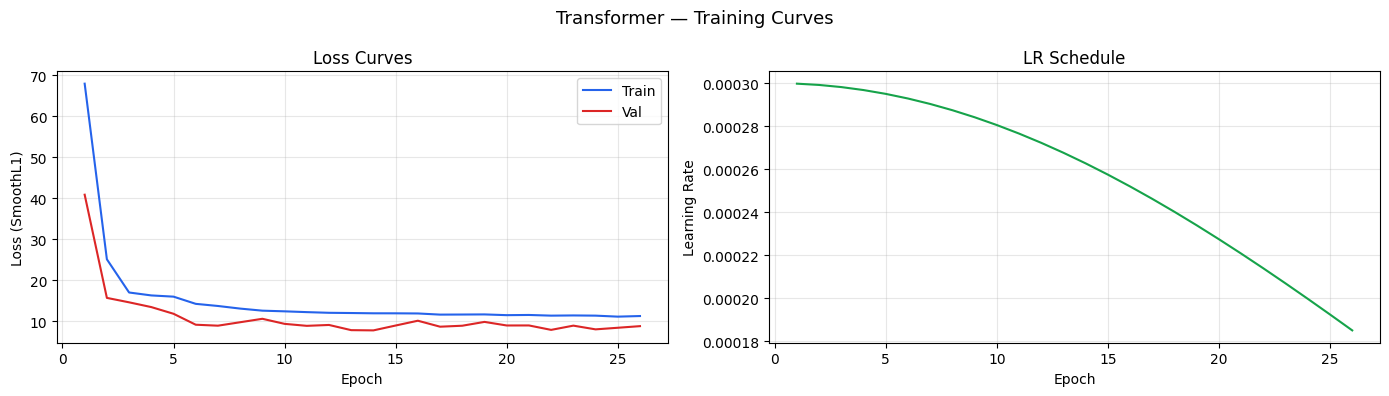

Saved: results/tf_curves.png


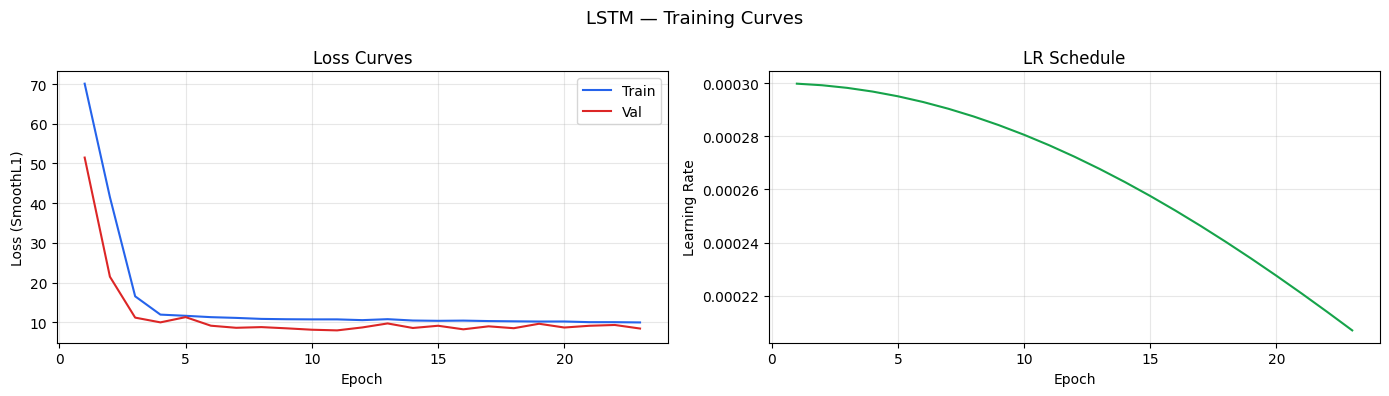

Saved: results/lstm_curves.png


In [ ]:
def plot_training_curves(hist, title, save_path):
    ep = range(1, len(hist['train'])+1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(title, fontsize=13)
    axes[0].plot(ep, hist['train'], label='Train', color='#2563EB', lw=1.5)
    axes[0].plot(ep, hist['val'],   label='Val',   color='#DC2626', lw=1.5)
    axes[0].set(xlabel='Epoch', ylabel='Loss (SmoothL1)', title='Loss Curves')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(ep, hist['lr'], color='#16A34A', lw=1.5)
    axes[1].set(xlabel='Epoch', ylabel='Learning Rate', title='LR Schedule')
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f'Saved: {save_path}')

plot_training_curves(tf_history,   'Transformer — Training Curves', 'results/tf_curves.png')
plot_training_curves(lstm_history, 'LSTM — Training Curves',        'results/lstm_curves.png')

---
## 13-Prepare Test Set & Evaluate Deep Models

---
## 13a- Evaluation Function (Deep Models)

In [ ]:
## Cell 13a — Evaluation Function

def evaluate_model(model, X, y_true, label='Model'):
    model.eval()
    preds = []

    with torch.no_grad():
        for i in range(0, len(X), 64):
            Xb = torch.tensor(X[i:i+64], dtype=torch.float32).to(DEVICE)
            preds.extend(model(Xb).cpu().numpy())

    pred_raw = np.array(preds, dtype=np.float32)
    pred = pred_raw
    y_true_real = y_true

    # metrics (NO clipping for R²)
    rmse = float(np.sqrt(mean_squared_error(y_true_real, pred)))
    mae  = float(mean_absolute_error(y_true_real, pred))
    r2   = float(r2_score(y_true_real, pred))

    # NASA score uses clipped values ONLY
    pred_clipped = np.clip(pred_raw, 0, CLIP_RUL)
    errors = pred_clipped - y_true_real

    score = float(np.sum(np.where(
        errors < 0,
        np.exp(-errors / 13.0) - 1,
        np.exp(errors / 10.0) - 1
    )))

    print(f'\n── {label} ────────────────────────')
    print(f'  RMSE       : {rmse:.4f}')
    print(f'  MAE        : {mae:.4f}')
    print(f'  R²         : {r2:.4f}')
    print(f'  NASA Score : {score:.2f}')
    print(f'  Pred range : [{pred.min():.1f}, {pred.max():.1f}]')
    print(f'  True range : [{y_true_real.min():.1f}, {y_true_real.max():.1f}]')

    return {
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'score': score,
        'preds': pred,
        'actuals': y_true_real,
        'label': label
    }

In [ ]:
# ── Prepare test set ──────────────────────────────────────────
# NOTE: loads test sequences and official NASA ground-truth RUL
X_test, y_test = prepare_test(TEST_PATH, RUL_PATH, scaler=scaler, seq_len=SEQ_LEN)
print(f'Test sequences : {X_test.shape}')
print(f'True RUL stats : mean={y_test.mean():.1f}, std={y_test.std():.1f}, '
      f'min={y_test.min():.0f}, max={y_test.max():.0f}')

# ── Evaluate deep models ───────────────────────────────────────
# evaluate_model() defined in previous cell (Cell 13a)
tf_scores   = evaluate_model(tf_model,   X_test, y_test, 'Transformer')
lstm_scores = evaluate_model(lstm_model, X_test, y_test, 'LSTM Baseline')

  Detected 26 columns in test_FD001.txt
Test sequences : (100, 30, 14)
True RUL stats : mean=74.5, std=40.1, min=7, max=125

── Transformer ────────────────────────
  RMSE       : 13.0199
  MAE        : 9.5920
  R²         : 0.8944
  NASA Score : 288.80
  Pred range : [4.1, 124.0]
  True range : [7.0, 125.0]

── LSTM Baseline ────────────────────────
  RMSE       : 13.1207
  MAE        : 9.6739
  R²         : 0.8928
  NASA Score : 240.41
  Pred range : [4.2, 124.1]
  True range : [7.0, 125.0]


---
## 14-Prediction Plots

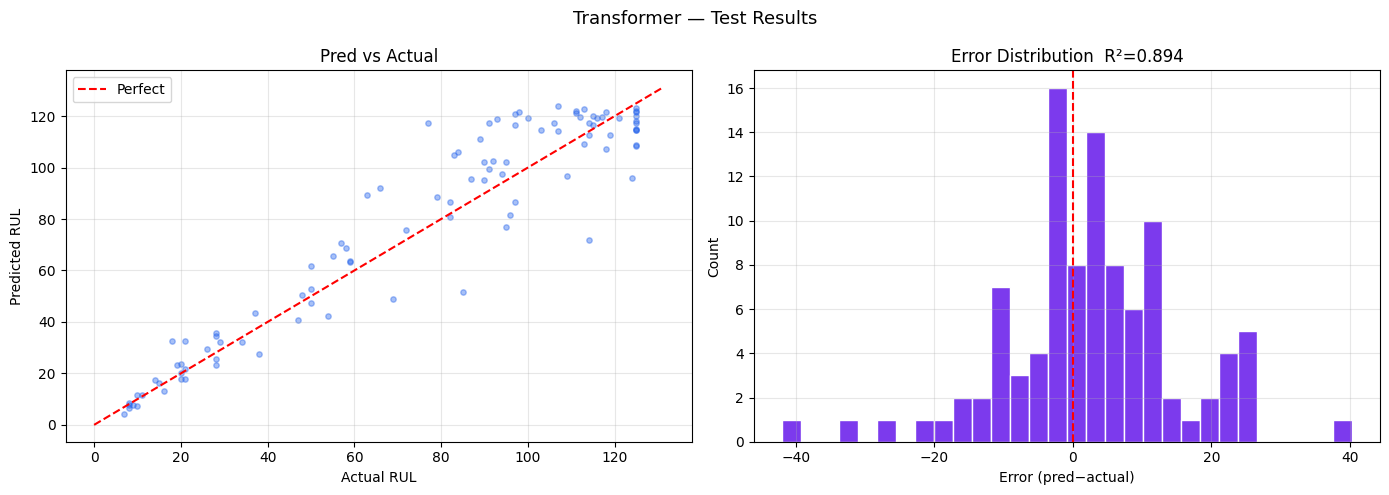

Saved: results/tf_preds.png


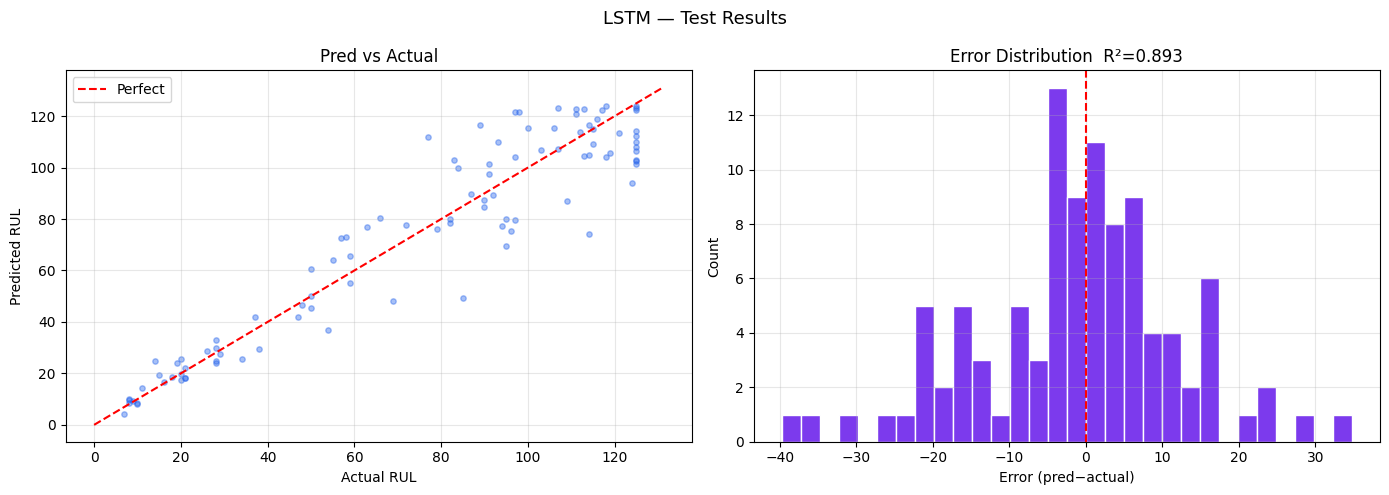

Saved: results/lstm_preds.png


In [ ]:
def plot_predictions(scores, title, save_path):
    p, a = scores['preds'], scores['actuals']
    lim  = max(a.max(), p.max()) * 1.05
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13)
    axes[0].scatter(a, p, alpha=0.4, s=15, color='#2563EB')
    axes[0].plot([0,lim],[0,lim], 'r--', lw=1.5, label='Perfect')
    axes[0].set(xlabel='Actual RUL', ylabel='Predicted RUL', title='Pred vs Actual')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    err = p - a
    axes[1].hist(err, bins=30, color='#7C3AED', edgecolor='white', lw=0.5)
    axes[1].axvline(0, color='red', ls='--', lw=1.5)
    axes[1].set(xlabel='Error (pred−actual)', ylabel='Count',
                title=f'Error Distribution  R²={scores["r2"]:.3f}')
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f'Saved: {save_path}')

plot_predictions(tf_scores,   'Transformer — Test Results',   'results/tf_preds.png')
plot_predictions(lstm_scores, 'LSTM — Test Results',          'results/lstm_preds.png')

---
## 15- Linear Regression Baseline

In [ ]:
# FIX: StandardScaler on flattened train features (fit on train only)
# Requires: X_train_flat (Cell 7), X_test (Cell 28), y_test (Cell 28)
lr_scaler   = StandardScaler()
X_train_sc  = lr_scaler.fit_transform(X_train_flat)

# Flatten and scale test set (defined HERE, used in Cell 34 too)
X_test_flat = X_test.reshape(len(X_test), -1)
X_test_sc   = lr_scaler.transform(X_test_flat)

lr_model = LinearRegression()
lr_model.fit(X_train_sc, y_train)

lr_pred   = np.clip(lr_model.predict(X_test_sc), 0, CLIP_RUL).astype(np.float32)
lr_rmse   = float(np.sqrt(mean_squared_error(y_test, lr_pred)))
lr_mae    = float(mean_absolute_error(y_test, lr_pred))
lr_r2     = float(r2_score(y_test, lr_pred))
lr_errors = lr_pred - y_test
lr_score  = float(np.sum(np.where(lr_errors < 0,
                                   np.exp(-lr_errors/13.0)-1,
                                   np.exp( lr_errors/10.0)-1)))
lr_scores = {'rmse':lr_rmse,'mae':lr_mae,'r2':lr_r2,'score':lr_score,
             'preds':lr_pred,'actuals':y_test,'label':'Linear Regression'}

print('── Linear Regression (with StandardScaler) ──────────')
print(f'  RMSE       : {lr_rmse:.4f}')
print(f'  MAE        : {lr_mae:.4f}')
print(f'  R²         : {lr_r2:.4f}')
print(f'  NASA Score : {lr_score:.2f}  (lower is better)')

── Linear Regression (with StandardScaler) ──────────
  RMSE       : 14.7602
  MAE        : 11.9787
  R²         : 0.8643
  NASA Score : 374.41  (lower is better)


---
## 16-Random Forest Baseline

In [ ]:
# Requires: X_train_flat (Cell 7), X_test_flat (Cell 15/LR cell), y_test (Cell 13b)
print(f'Training Random Forest ({RF_N_ESTIMATORS} trees, max_depth={RF_MAX_DEPTH})...')
print('This may take 3-5 min on Colab CPU — normal, RF trains on 420 features.')
rf_model = RandomForestRegressor(
    n_estimators  = RF_N_ESTIMATORS,
    max_depth     = RF_MAX_DEPTH,
    min_samples_leaf = 2,
    n_jobs        = -1,
    random_state  = SEED
)
rf_model.fit(X_train_flat, y_train)

# X_test_flat defined in LR cell (Cell 15) — uses MinMax normalised features
rf_pred   = np.clip(rf_model.predict(X_test_flat), 0, CLIP_RUL).astype(np.float32)
rf_rmse   = float(np.sqrt(mean_squared_error(y_test, rf_pred)))
rf_mae    = float(mean_absolute_error(y_test, rf_pred))
rf_r2     = float(r2_score(y_test, rf_pred))
rf_errors = rf_pred - y_test
rf_score  = float(np.sum(np.where(rf_errors < 0,
                                   np.exp(-rf_errors/13.0)-1,
                                   np.exp( rf_errors/10.0)-1)))
rf_scores = {'rmse':rf_rmse,'mae':rf_mae,'r2':rf_r2,'score':rf_score,
             'preds':rf_pred,'actuals':y_test,'label':'Random Forest'}

print('── Random Forest ────────────────────────────────────')
print(f'  RMSE       : {rf_rmse:.4f}')
print(f'  MAE        : {rf_mae:.4f}')
print(f'  R²         : {rf_r2:.4f}')
print(f'  NASA Score : {rf_score:.2f}  (lower is better)')

Training Random Forest (300 trees, max_depth=15)...
This may take 3-5 min on Colab CPU — normal, RF trains on 420 features.
── Random Forest ────────────────────────────────────
  RMSE       : 16.4736
  MAE        : 12.0117
  R²         : 0.8310
  NASA Score : 742.66  (lower is better)


---
## 17- Full Comparison Table & Charts


  MODEL                     RMSE     MAE      R²
  Linear Regression      14.7602 11.9787  0.8643
  Random Forest          16.4736 12.0117  0.8310
  LSTM Baseline          13.1207  9.6739  0.8928
  Transformer            13.0199  9.5920  0.8944  ◀ best RMSE


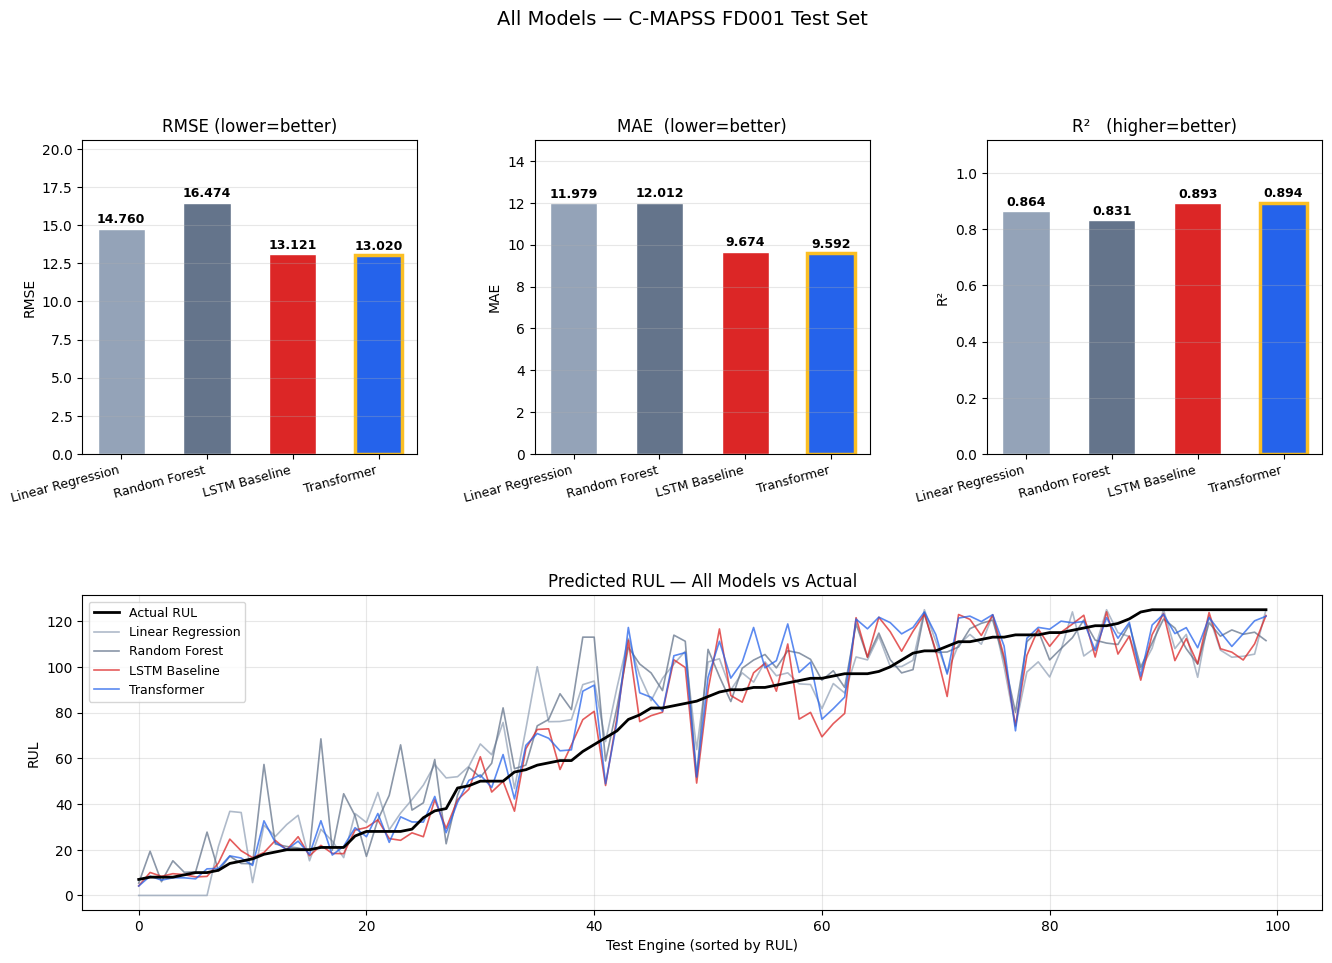

Saved: results/full_comparison.png


In [ ]:
all_models = {
    'Linear Regression' : lr_scores,
    'Random Forest'     : rf_scores,
    'LSTM Baseline'     : lstm_scores,
    'Transformer'       : tf_scores,
}

# ── Print table ────────────────────────────────────────────────
print('\n' + '='*54)
print(f'  {"MODEL":<22} {"RMSE":>7} {"MAE":>7} {"R²":>7}')
print('='*54)
for name, s in all_models.items():
    tag = '  ◀ best RMSE' if s['rmse'] == min(sc['rmse'] for sc in all_models.values()) else ''
    print(f'  {name:<22} {s["rmse"]:>7.4f} {s["mae"]:>7.4f} {s["r2"]:>7.4f}{tag}')
print('='*54)

# ── Bar charts ────────────────────────────────────────────────
names   = list(all_models.keys())
rmses   = [all_models[m]['rmse'] for m in names]
maes    = [all_models[m]['mae']  for m in names]
r2s     = [all_models[m]['r2']   for m in names]
palette = ['#94A3B8','#64748B','#DC2626','#2563EB']

def bar_chart(ax, vals, title, ylabel, names, palette, highlight_max=False):
    bars = ax.bar(names, vals, color=palette, edgecolor='white', width=0.55)
    best = vals.index(max(vals)) if highlight_max else vals.index(min(vals))
    bars[best].set_edgecolor('#FBBF24'); bars[best].set_linewidth(2.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set(title=title, ylabel=ylabel)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
    ax.set_ylim(0, max(vals)*1.25)
    ax.grid(alpha=0.3, axis='y')

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
ax_rmse = fig.add_subplot(gs[0, 0])
ax_mae  = fig.add_subplot(gs[0, 1])
ax_r2   = fig.add_subplot(gs[0, 2])
ax_pred = fig.add_subplot(gs[1, :])
fig.suptitle('All Models — C-MAPSS FD001 Test Set', fontsize=14, y=1.01)

bar_chart(ax_rmse, rmses, 'RMSE (lower=better)', 'RMSE', names, palette)
bar_chart(ax_mae,  maes,  'MAE  (lower=better)', 'MAE',  names, palette)
bar_chart(ax_r2,   r2s,   'R²   (higher=better)','R²',   names, palette, highlight_max=True)

# Prediction overlay — single Actual line, no duplicate legend
sorted_idx = np.argsort(all_models['Transformer']['actuals'])
ax_pred.plot(all_models['Transformer']['actuals'][sorted_idx],
             color='black', lw=2, zorder=5, label='Actual RUL')
for (name, s), col in zip(all_models.items(), palette):
    ax_pred.plot(s['preds'][sorted_idx], color=col, alpha=0.75, lw=1.2, label=name)
ax_pred.set(xlabel='Test Engine (sorted by RUL)', ylabel='RUL',
            title='Predicted RUL — All Models vs Actual')
ax_pred.legend(loc='upper left', fontsize=9)
ax_pred.grid(alpha=0.3)

plt.savefig('results/full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/full_comparison.png')

---
## Cell 18 — Save All Models

In [ ]:
# Deep learning models
torch.save(tf_model.state_dict(),   'results/final_transformer.pth')
torch.save(lstm_model.state_dict(), 'results/final_lstm.pth')

# Sklearn models (pickle)
with open('results/linear_regression.pkl','wb') as f: pickle.dump(lr_model, f)
with open('results/random_forest.pkl','wb')    as f: pickle.dump(rf_model, f)

print('All models saved.')
print('\nFiles in results/:')
for fname in sorted(os.listdir('results')):
    size = os.path.getsize(f'results/{fname}')
    print(f'  {fname:<40} {size/1024:.1f} KB')

All models saved.

Files in results/:
  best_lstm.pth                            570.0 KB
  best_transformer.pth                     1868.9 KB
  eda.png                                  313.9 KB
  final_lstm.pth                           569.9 KB
  final_transformer.pth                    1868.9 KB
  full_comparison.png                      308.6 KB
  linear_regression.pkl                    3.7 KB
  lstm_curves.png                          81.7 KB
  lstm_preds.png                           87.6 KB
  random_forest.pkl                        96386.5 KB
  tf_curves.png                            88.0 KB
  tf_preds.png                             89.3 KB


---
## Cell 19 — Download Results

In [ ]:
from google.colab import files

# FIX: filenames match exactly what was saved in Cells 12, 14, 17
to_download = [
    'results/eda.png',
    'results/tf_curves.png',
    'results/lstm_curves.png',
    'results/tf_preds.png',
    'results/lstm_preds.png',
    'results/full_comparison.png',      # saved in Cell 17
    'results/final_transformer.pth',
    'results/final_lstm.pth',
    'results/linear_regression.pkl',
    'results/random_forest.pkl',
]

for fpath in to_download:
    if os.path.exists(fpath):
        files.download(fpath)
        print(f'Downloading : {fpath}')
    else:
        print(f'Skipped (not found) : {fpath}')
print('Done.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done.
